In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import sys
import os
import pickle

from scipy.optimize import curve_fit

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data
import cigar as cig

from tqdm import tqdm

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
colors = ['royalblue', 'crimson', 'green', 'darkorange', 'brown', 'blue', 'coral', 'indigo', 'magenta', 'black']
CB_MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']

font_size = 20
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size


##  Runs

Inputs: one {pressure: run} dict per gas — the same signal runs ChargeSpectrum.ipynb reads for the charge spectrum (all channels packed into each .bin file, one run directory), not the dedicated per-channel SPhe calibration runs used in `FingerPlot4CHs.ipynb`. DCR is computed from the noise tail of these waveforms — everything after ChargeSpectrum.ipynb's signal integration window — instead of from a separate calibration run.

The values below match `ChargeSpectrum.ipynb`'s own `runs`/`temperatures` dicts — adjust if your campaign used different runs.

In [3]:
base = "/home/marian/CIGAR_ANALYSIS/CIGAR/data"

# {pressure [bar]: run} - same signal runs read by ChargeSpectrum.ipynb (all
# 10 channels packed into each .bin file, one run per directory). DCR is now
# computed from the noise tail of these waveforms instead of from a
# dedicated per-channel SPhe calibration run.
runs = {
    'Xe': {8.5: 'Run75', 7.5: 'Run77', 6.5: 'Run80', 5.5: 'Run83',
           4.5: 'Run103', 3.5: 'Run105', 2.5: 'Run111', 1.5: 'Run114'},
    'Ar': {8.5: 'Run171', 7.5: 'Run173', 6.5: 'Run175', 5.5: 'Run177',
           4.5: 'Run179', 3.5: 'Run181', 2.5: 'Run183', 1.5: 'Run185'},
}

# temp labels matching cigar.ChargeToPes' calibration tables (ConvPar keys),
# same as used in ChargeSpectrum.ipynb / ChargeVSPressure.ipynb for each gas
temperatures = {
    'Xe': {8.5: '8deg', 7.5: '10deg', 6.5: '12deg', 5.5: '13deg',
           4.5: '11.5deg', 3.5: '13v2deg', 2.5: '13v3deg', 1.5: '14deg'},
    'Ar': {8.5: '6deg', 7.5: '7deg', 6.5: '8deg', 5.5: '9deg',
           4.5: '10deg', 3.5: '11deg', 2.5: '12deg', 1.5: '13.5deg'},
}

# DAQ parameters for these runs (see ChargeSpectrum.ipynb) - same 10-channel
# digitizer format as the main physics runs, unlike the old per-channel SPhe
# calibration runs (1 channel per .bin file)
new_board           = True
nchannels           = 10       # channels packed into each .bin file
nevents_per_wvf     = 500
event_header_bytes  = 28
sample_binning      = 8e-9     # seconds/sample

start  = 0
nfiles = None   # None = read every file in the run directory; lower this for a quick test

# --- Amp / non-Amp channel groups - new_board flips which physical group is
# amplified (see ChargeSpectrum.ipynb). DCR here is computed on the
# NON-amplified channels.
A_chs   = ['CH4', 'CH6', 'CH8', 'CH10']
noA_chs = ['CH3', 'CH5', 'CH7', 'CH9']

if new_board:
    Amp_channels   = noA_chs
    noAmp_channels = A_chs
else:
    Amp_channels   = A_chs
    noAmp_channels = noA_chs

channels = noAmp_channels   # DCR is computed on the non-amplified channels

# Projects a non-amplified sample onto the amplified channels' scale, via
# (v - b) / m, so the same ChargeToPes calibration (fit on amplified data)
# still applies - same values and same manual pre-scaling as
# ChargeSpectrum.ipynb (see compute_charge_pes below)
amp_factors = {'CH1': (-1/350, 0), 'CH2': (-1/349, 0),
               'CH3': (-1/350, 0), 'CH4': (-1/341, 0)}


##  Reading + dark count rate computation

In [4]:
def load_run(run, base_dir, nchannels, nevents_per_wvf, samples_per_waveform,
             event_header_bytes, start=0, nfiles=None, sample_binning=8e-9):
    """
    Reads one signal run into a single DataFrame - same format and method
    as ChargeSpectrum.ipynb (all channels packed into each .bin file, one
    run per directory), unlike the old per-channel SPhe calibration runs.
    """
    run_dir = f'{base_dir}/{run}'

    dataframes = []
    for i, file in enumerate(tqdm(os.listdir(run_dir)[start:nfiles],
                                   desc=f'Reading {run} .bin files', unit='file')):
        if file.endswith('.bin'):
            file_path = os.path.join(run_dir, file)
            df_tmp = parse_data.parse_wf_from_binary(
                file_path,
                channels=nchannels,
                n_events=nevents_per_wvf,
                file_idx=i,
                event_header_bytes=event_header_bytes,
                sample_binning=sample_binning
            )
            dataframes.append(df_tmp)

    return pd.concat(dataframes, ignore_index=True)


In [5]:
def compute_charge_pes(df, channels, position, temp_label, gas, baselines, amp_factors,
                        time_window, sample_binning=8e-9):
    """
    For one non-amplified channel of a run: integrates only the noise-tail
    time_window (everything AFTER ChargeSpectrum.ipynb's signal window - see
    the "Integration window" section below) and converts the integral to
    photoelectrons with the (gas, temp_label) calibration. Before
    integrating, the baseline-corrected samples are projected onto the
    amplified channels' scale via amp_factors ((v - b) / m) - the same
    manual pre-scaling ChargeSpectrum.ipynb applies to its non-amplified
    channels before calling ChargeToPes(amplified=True). (Note this is NOT
    the same transform as cig.ChargeToPes's own amplified=False branch,
    which multiplies by m instead of dividing - using that here would
    silently apply the amp factor inverted.) Returns one charge value
    [p.e.] per waveform, the integration window's duration [s], and the
    (shared) time axis, both needed downstream by compute_dcr_values.
    """
    ch      = channels[position]
    channel = position + 1

    event_list = df['event'].unique()
    nevents    = len(event_list)

    voltage  = df[ch].values
    v_matrix = voltage.reshape(nevents, -1)

    v_matrix_corrected = v_matrix - baselines[f'CH{channel}']

    m, b = amp_factors[f'CH{channel}']
    v_matrix_amplified = (v_matrix_corrected - b) / m

    t_matrix = df['TIME'].values.reshape(nevents, -1)
    time     = t_matrix[0]

    # noise-tail integral in mV*s - NOT the signal window, its complement on
    # the trailing side (time_window = time > ChargeSpectrum's time_window_max)
    charge = np.trapz(v_matrix_amplified[:, time_window], x=time[time_window], axis=1)

    charge_pes = cig.ChargeToPes(charge, channel=channel, temp=temp_label, gas=gas, amplified=True)

    window_duration = time_window.sum() * sample_binning

    return charge_pes, window_duration, time


def compute_dcr_values(df, channels, position, temp_label, gas, baselines, amp_factors,
                        time_window, sample_binning=8e-9):
    """
    Divides each waveform's noise-tail charge [p.e.] (see compute_charge_pes)
    by the integration window's time span. Returns one dark-count-rate value
    [MHz] per waveform.
    """
    charge_pes, window_duration, _ = compute_charge_pes(df, channels, position, temp_label, gas,
                                                          baselines, amp_factors, time_window,
                                                          sample_binning=sample_binning)
    dcr_values_hz = charge_pes / window_duration
    dcr_values    = dcr_values_hz / 1e6   # Hz -> MHz

    return dcr_values

In [6]:
def fit_dcr_distribution(dcr_values, nbins=None):
    """
    Histograms per-waveform dark-count-rate values and fits a Generalized
    Poisson / Borel-Poisson distribution (Consul & Jain 1973; Vinogradov
    2012 for the SiPM application): a Poisson(theta) number of primary dark
    pulses, each independently spawning a Borel(lam)-distributed
    crosstalk/afterpulse cascade. lam=0 recovers plain Poisson. This
    captures the super-Poissonian tail from correlated SiPM noise that a
    plain Poisson (or Gaussian) can't reproduce.

    The histogram covers the full range of dcr_values (so the plot still
    shows the true data, including the negative tail from baseline noise
    on zero-dark-count waveforms), but only bins with rate > 0 are passed
    to the fit - the Generalized Poisson has no support below 0 anyway,
    and that tail isn't part of the counting process it describes.

    Returns the fitted mean DCR (mu = theta / (1 - lam)) and its
    uncertainty, and the crosstalk probability (lam, 0-1) and its
    uncertainty.
    """
    if nbins is None:
        nbins = max(int(0.7*np.sqrt(len(dcr_values))), 10)

    counts, bins = np.histogram(dcr_values, bins=nbins
                                # , range = (-5, 15)
                                )
    bin_centers  = 0.5 * (bins[:-1] + bins[1:])

    bin0 = .01

    fit_mask    = bin_centers > bin0
    fit_centers = bin_centers[fit_mask]
    fit_counts  = counts[fit_mask]

    positive_values = dcr_values[dcr_values > bin0]
    sample_mean = max(np.mean(positive_values), 1e-3)
    sample_var  = np.var(positive_values)

    # method-of-moments starting point: Var/Mean = 1/(1-lam)**2 for a GPD
    lam0   = np.clip(1 - np.sqrt(sample_mean / sample_var), 0.0, 0.9) if sample_var > 0 else 0.0
    theta0 = sample_mean * (1 - lam0)
    A0     = fit_counts.max()

    try:
        popt, pcov = curve_fit(cig.generalized_poisson_continuous, fit_centers, fit_counts,
                                p0=[A0, theta0, lam0],
                                bounds=([0, 1e-6, 0], [np.inf, np.inf, 0.95]),
                                maxfev=20000)
        A, theta, lam = popt

        mu         = theta / (1 - lam)
        dmu_dtheta = 1 / (1 - lam)
        dmu_dlam   = theta / (1 - lam) ** 2
        var_mu     = (dmu_dtheta ** 2 * pcov[1, 1] + dmu_dlam ** 2 * pcov[2, 2]
                      + 2 * dmu_dtheta * dmu_dlam * pcov[1, 2])
        mu_err  = np.sqrt(max(var_mu, 0))
        lam_err = np.sqrt(pcov[2, 2])
    except RuntimeError:
        print('Generalized Poisson fit failed - falling back to sample mean/std.')
        popt    = [A0, theta0, lam0]
        mu      = sample_mean
        mu_err  = np.std(positive_values) / np.sqrt(len(positive_values))
        lam     = lam0
        lam_err = np.nan

    return dict(mu=mu, mu_err=mu_err, lam=lam, lam_err=lam_err,
                popt=popt, counts=counts, bins=bins, bin_centers=fit_centers)


##  Step-by-step example: one run

Pick one `(gas, pressure)` pair and walk through the full pipeline - waveform density, integration window, the resulting charge distribution [p.e.], and the DCR distribution [MHz] it implies - before running every pressure at the end. `gas` chosen here also drives the "all pressures" pass at the end of the notebook; it is not looped over.

In [7]:
# --- everything below (including the "all pressures" pass at the end) uses this gas ---
gas = 'Ar'   # 'Xe' or 'Ar'

# which single run to walk through step by step first
example_pressure = 8.5   # [bar]

# waveform length depends on gas - same as ChargeSpectrum.ipynb
samples_per_waveform = 1124 if gas == 'Xe' else 2000

In [8]:
run        = runs[gas][example_pressure]
temp_label = temperatures[gas][example_pressure]

df_example = load_run(run, base, nchannels, nevents_per_wvf, samples_per_waveform,
                       event_header_bytes, start=start, nfiles=nfiles,
                       sample_binning=sample_binning)

event_list = df_example['event'].unique()
nevents    = len(event_list)
print(f'{gas} @ {example_pressure} bar ({run}): {nevents} events')

Reading Run171 .bin files: 100%|██████████| 17/17 [01:57<00:00,  6.93s/file]


Ar @ 8.5 bar (Run171): 8500 events


###  Baseline

Same method as `ChargeSpectrum.ipynb`'s baseline-correction step (histogram the pretrigger samples, locate the peak with mode + local quadratic-in-log fit), computed on the non-amplified channels (`noAmp_channels`). Overwrites the hardcoded `fixBaselines_Amp` from the old per-channel setup with a value derived from this actual run - check the fitted red curve visually tracks the histogram peak.

In [9]:
def compute_baselines(df, nevents, pretrigger, channels, gas=None, pressure=None, run=None, plot=True):
    """
    Per-channel baseline offset from the pretrigger samples - same method
    as ChargeSpectrum.ipynb's "Baseline correction" step: histogram the
    first `pretrigger` samples of every waveform (no real signal should
    have arrived yet), then locate the peak by fitting a quadratic to
    log(counts + 1) in a small window around the tallest bin (equivalent
    to a local Gaussian fit, since the log of a Gaussian is a parabola,
    but more robust to noisy bins in the wings than fitting the raw counts
    directly). Falls back to the raw histogram mode if that fit fails.

    Returns a {'CH1': ..., 'CH2': ..., 'CH3': ..., 'CH4': ...} dict, keyed
    by logical channel position (1-4) rather than the physical column name
    in `channels` - the same convention ChargeSpectrum.ipynb uses for its
    fixBaselines_noAmp dict, and what compute_charge_pes/compute_dcr_values
    expect.
    """
    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
        title = f'Baseline (pretrigger={pretrigger})'
        if gas is not None:
            title += f' — {gas} @ {pressure} bar'
        if run:
            title += f' ({run})'
        fig.suptitle(title)
        axs_flat = axs.flatten()

    fixBaselines_noAmp = {}
    for i, ch in enumerate(channels):
        channel = i + 1

        voltage   = df[ch].values
        v_matrix  = voltage.reshape(nevents, -1)
        baselines = v_matrix[:, :pretrigger].flatten()

        counts, bins = np.histogram(baselines, bins=int(0.3 * np.sqrt(len(baselines))),
                                     range=(baselines.min(), baselines.max()))
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])
        mode_initial = bin_centers[np.argmax(counts)]

        bin_width = bins[1] - bins[0]
        window    = 0.05 * len(bins) * bin_width
        fit_mask  = (bin_centers >= mode_initial - window) & (bin_centers <= mode_initial + window)
        x_fit = bin_centers[fit_mask]
        y_fit = np.log(counts[fit_mask] + 1)

        coeffs = None
        try:
            coeffs = np.polyfit(x_fit, y_fit, 2)
            a, b, _ = coeffs
            peak_value = -b / (2 * a)
        except Exception:
            print(f'Baseline fit failed for {ch}, using histogram mode instead')
            peak_value = mode_initial

        fixBaselines_noAmp[f'CH{channel}'] = peak_value

        if plot:
            ax = axs_flat[i]
            ax.hist(baselines, bins=bins, color=colors[i], alpha=0.7, label=ch)
            if coeffs is not None:
                x_fine = np.linspace(x_fit.min(), x_fit.max(), 200)
                ax.plot(x_fine, np.exp(np.polyval(coeffs, x_fine)) - 1, '-r', lw=2, label='Quadratic fit')
            ax.axvline(peak_value, color='red', linestyle='--', lw=2, label=f'{peak_value:.1f} mV')
            ax.set_xlabel('Baseline [mV]')
            ax.set_ylabel('Counts')
            ax.set_yscale('log')
            ax.grid(True)
            ax.legend(fontsize=font_size * 0.7)

    if plot:
        plt.tight_layout()
        plt.show()

    return fixBaselines_noAmp

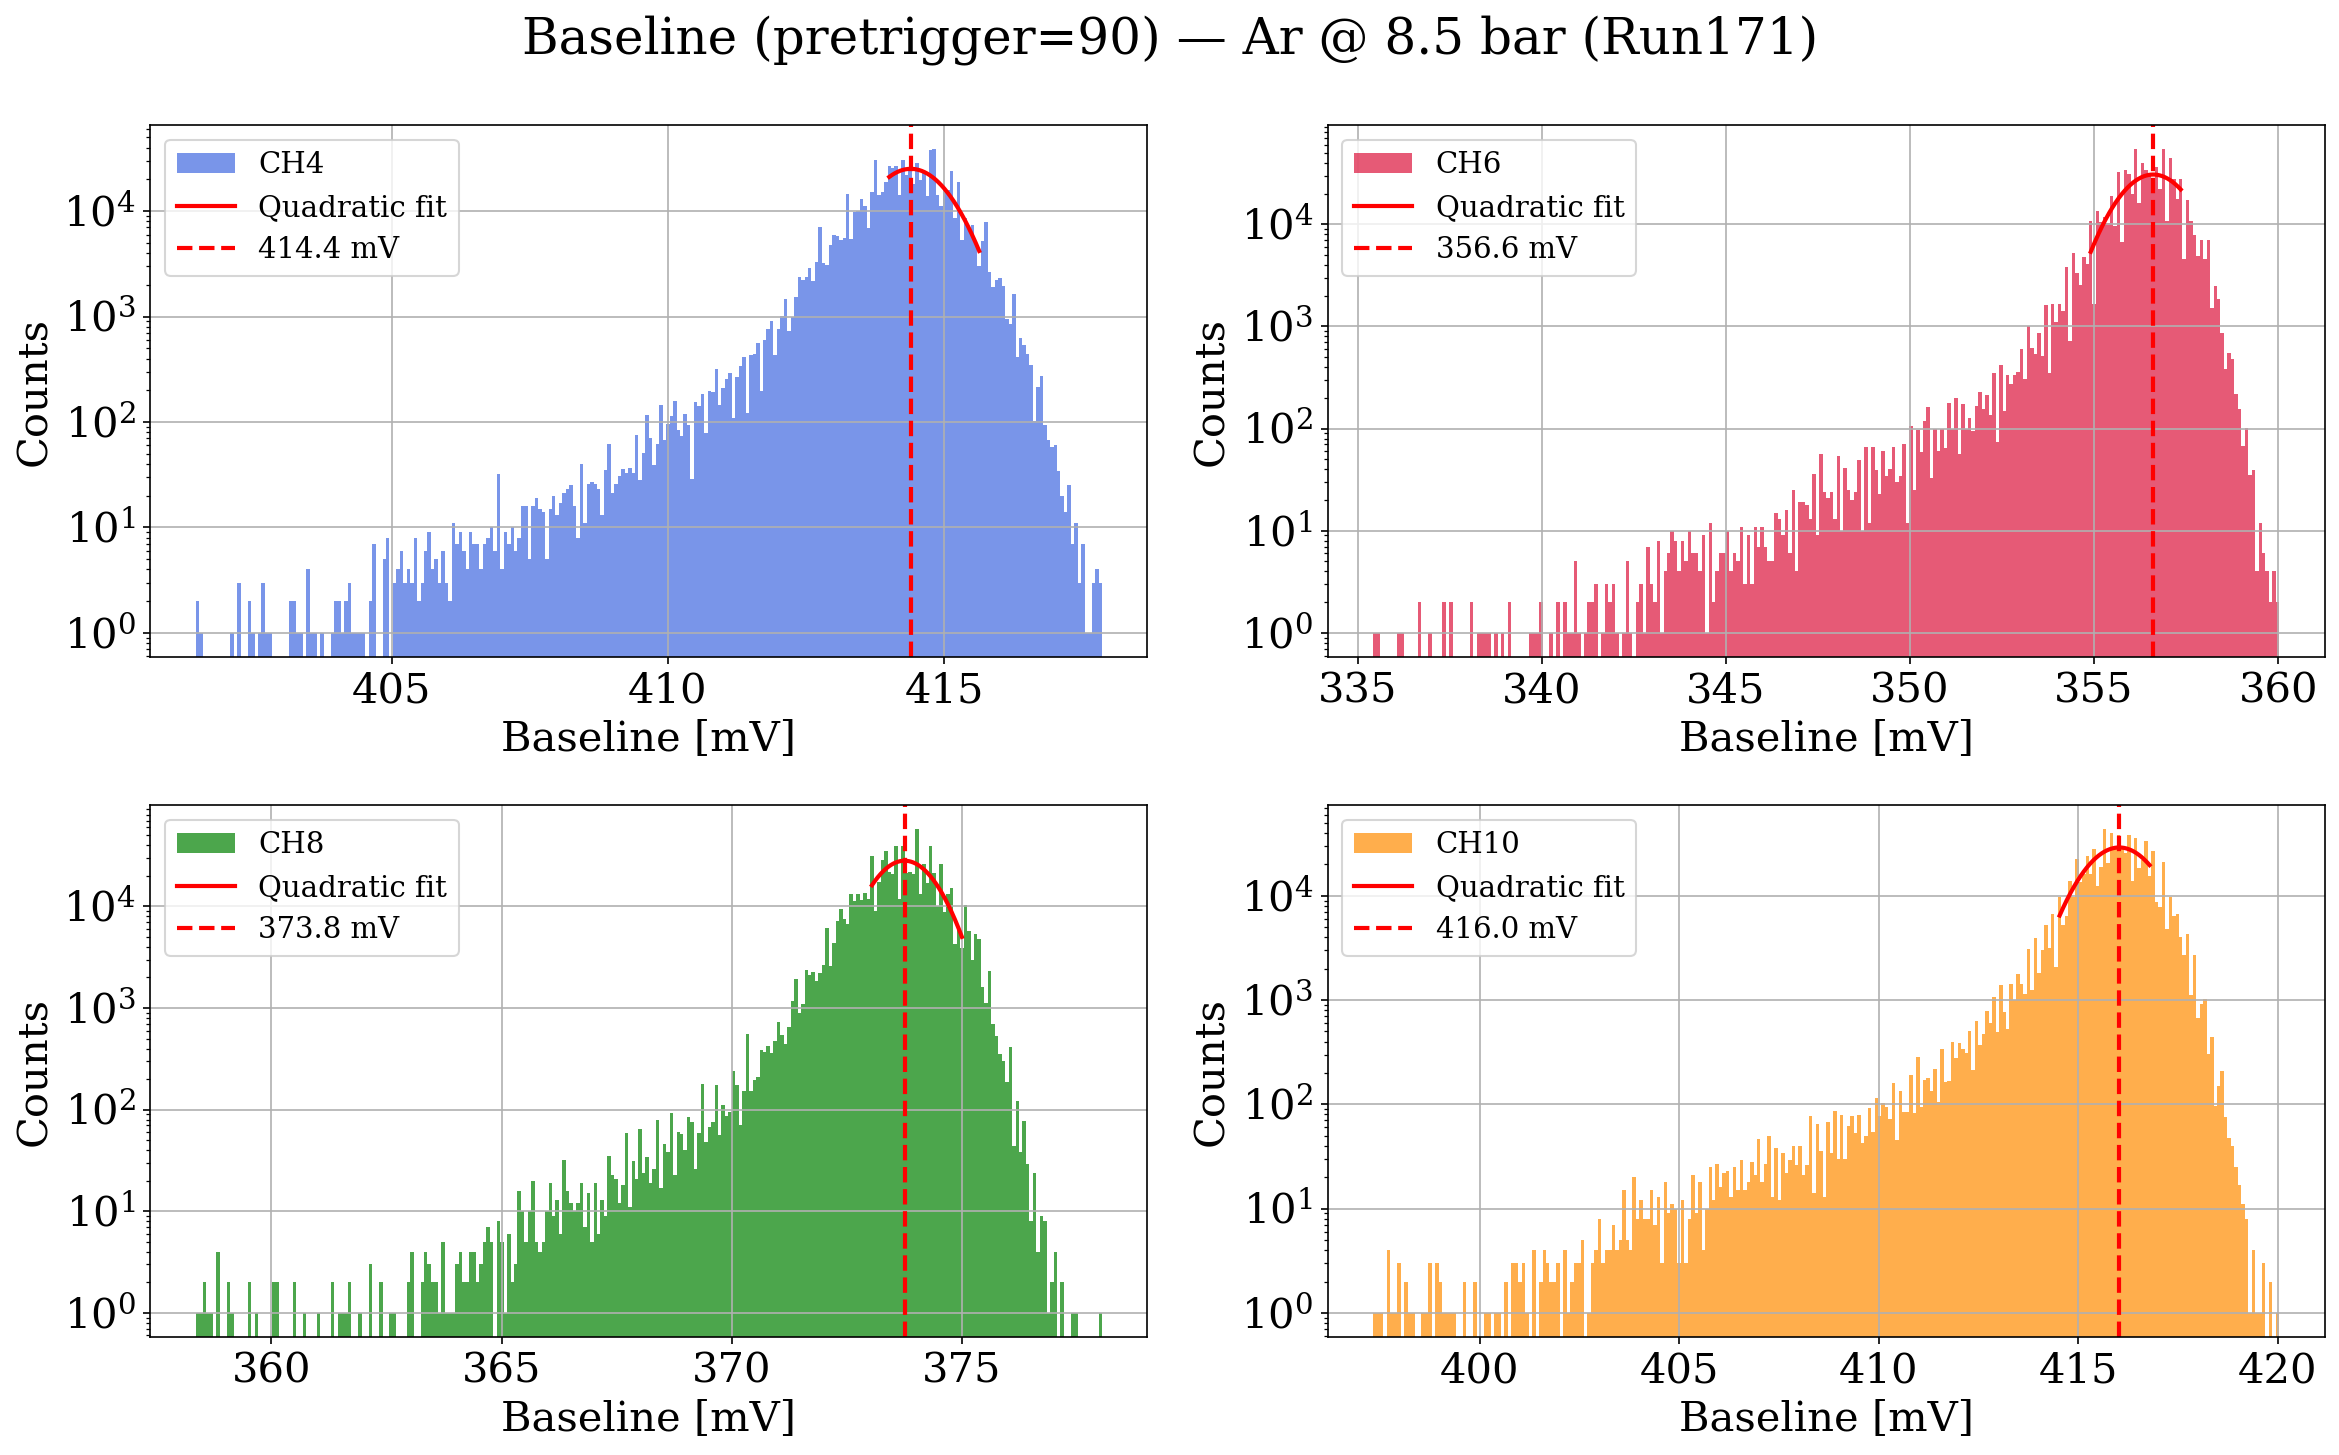

fixBaselines_noAmp: {'CH1': 414.39759228253075, 'CH2': 356.6065282013573, 'CH3': 373.7594416689553, 'CH4': 416.0318013682898}


In [10]:
pretrigger = 90 if new_board else 200   # pretrigger samples used as the baseline region - same as ChargeSpectrum.ipynb

fixBaselines_noAmp = compute_baselines(df_example, nevents, pretrigger, channels, gas, example_pressure, run, plot=True)
print('fixBaselines_noAmp:', fixBaselines_noAmp)

##  Waveform density + integration window

The DCR integration window starts exactly where ChargeSpectrum.ipynb's signal window ends (`time_window_max`) and runs to the end of the waveform - the noise-only tail that the charge spectrum excludes on the trailing side.

In [11]:
# --- ChargeSpectrum.ipynb's signal window (same definition, same values) ---
if new_board:
    time_window_min = 0.8e-6   # [s]
else:
    time_window_min = 1.7e-6   # [s]

if gas == 'Ar':
    time_window_max = time_window_min + 12e-6   # [s]
elif gas == 'Xe':
    time_window_max = time_window_min + 5e-6    # [s]

t_matrix = df_example['TIME'].values.reshape(nevents, -1)
time     = t_matrix[0]

# DCR integration window: everything AFTER the signal window - exactly what
# ChargeSpectrum.ipynb excludes on the trailing side
# time_window = time > time_window_max
time_window = time < time[pretrigger]

In [12]:
def plot_waveform_density(df, nevents, channels, baselines, time, time_window, gas, pressure, run):
    """
    2x2 grid, one hist2d per channel, showing where every waveform in the
    run sits in (time, ADC) space. The shaded band marks the DCR
    integration window used by compute_charge_pes() below - the noise tail
    AFTER ChargeSpectrum.ipynb's signal window (time > time_window_max).
    """
    fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi=150, sharex=True, sharey=False)
    fig.suptitle(f'Waveform density — {gas} @ {pressure} bar ({run})')
    axs_flat = axs.flatten()

    t_matrix = df['TIME'].values.reshape(nevents, -1)

    for i, ch in enumerate(channels):
        channel = i + 1
        ax = axs_flat[i]

        voltage            = df[ch].values
        v_matrix           = voltage.reshape(nevents, -1)
        v_matrix_corrected = v_matrix - baselines[f'CH{channel}']

        hb = ax.hist2d(t_matrix.flatten(), v_matrix_corrected.flatten(),
                       bins=[np.shape(t_matrix)[1], 200],
                       cmap='plasma', norm=mcolors.PowerNorm(gamma=0.3))
        cbar = fig.colorbar(hb[3], ax=ax, label='Counts')
        cbar.formatter.set_powerlimits((0, 0))
        cbar.formatter.set_useMathText(True)

        ax.fill_between(time[time_window], v_matrix_corrected.min(), v_matrix_corrected.max(),
                        color='white', alpha=0.25, label='Integration window (noise tail)')

        ax.set_title(ch)
        ax.set_ylabel('ADC [mV]')
        ax.set_xlabel('Time (s)')
        ax.grid(True)
        ax.legend(fontsize=font_size * 0.6, framealpha=0.5)

    plt.tight_layout()
    plt.show()
    return fig, axs

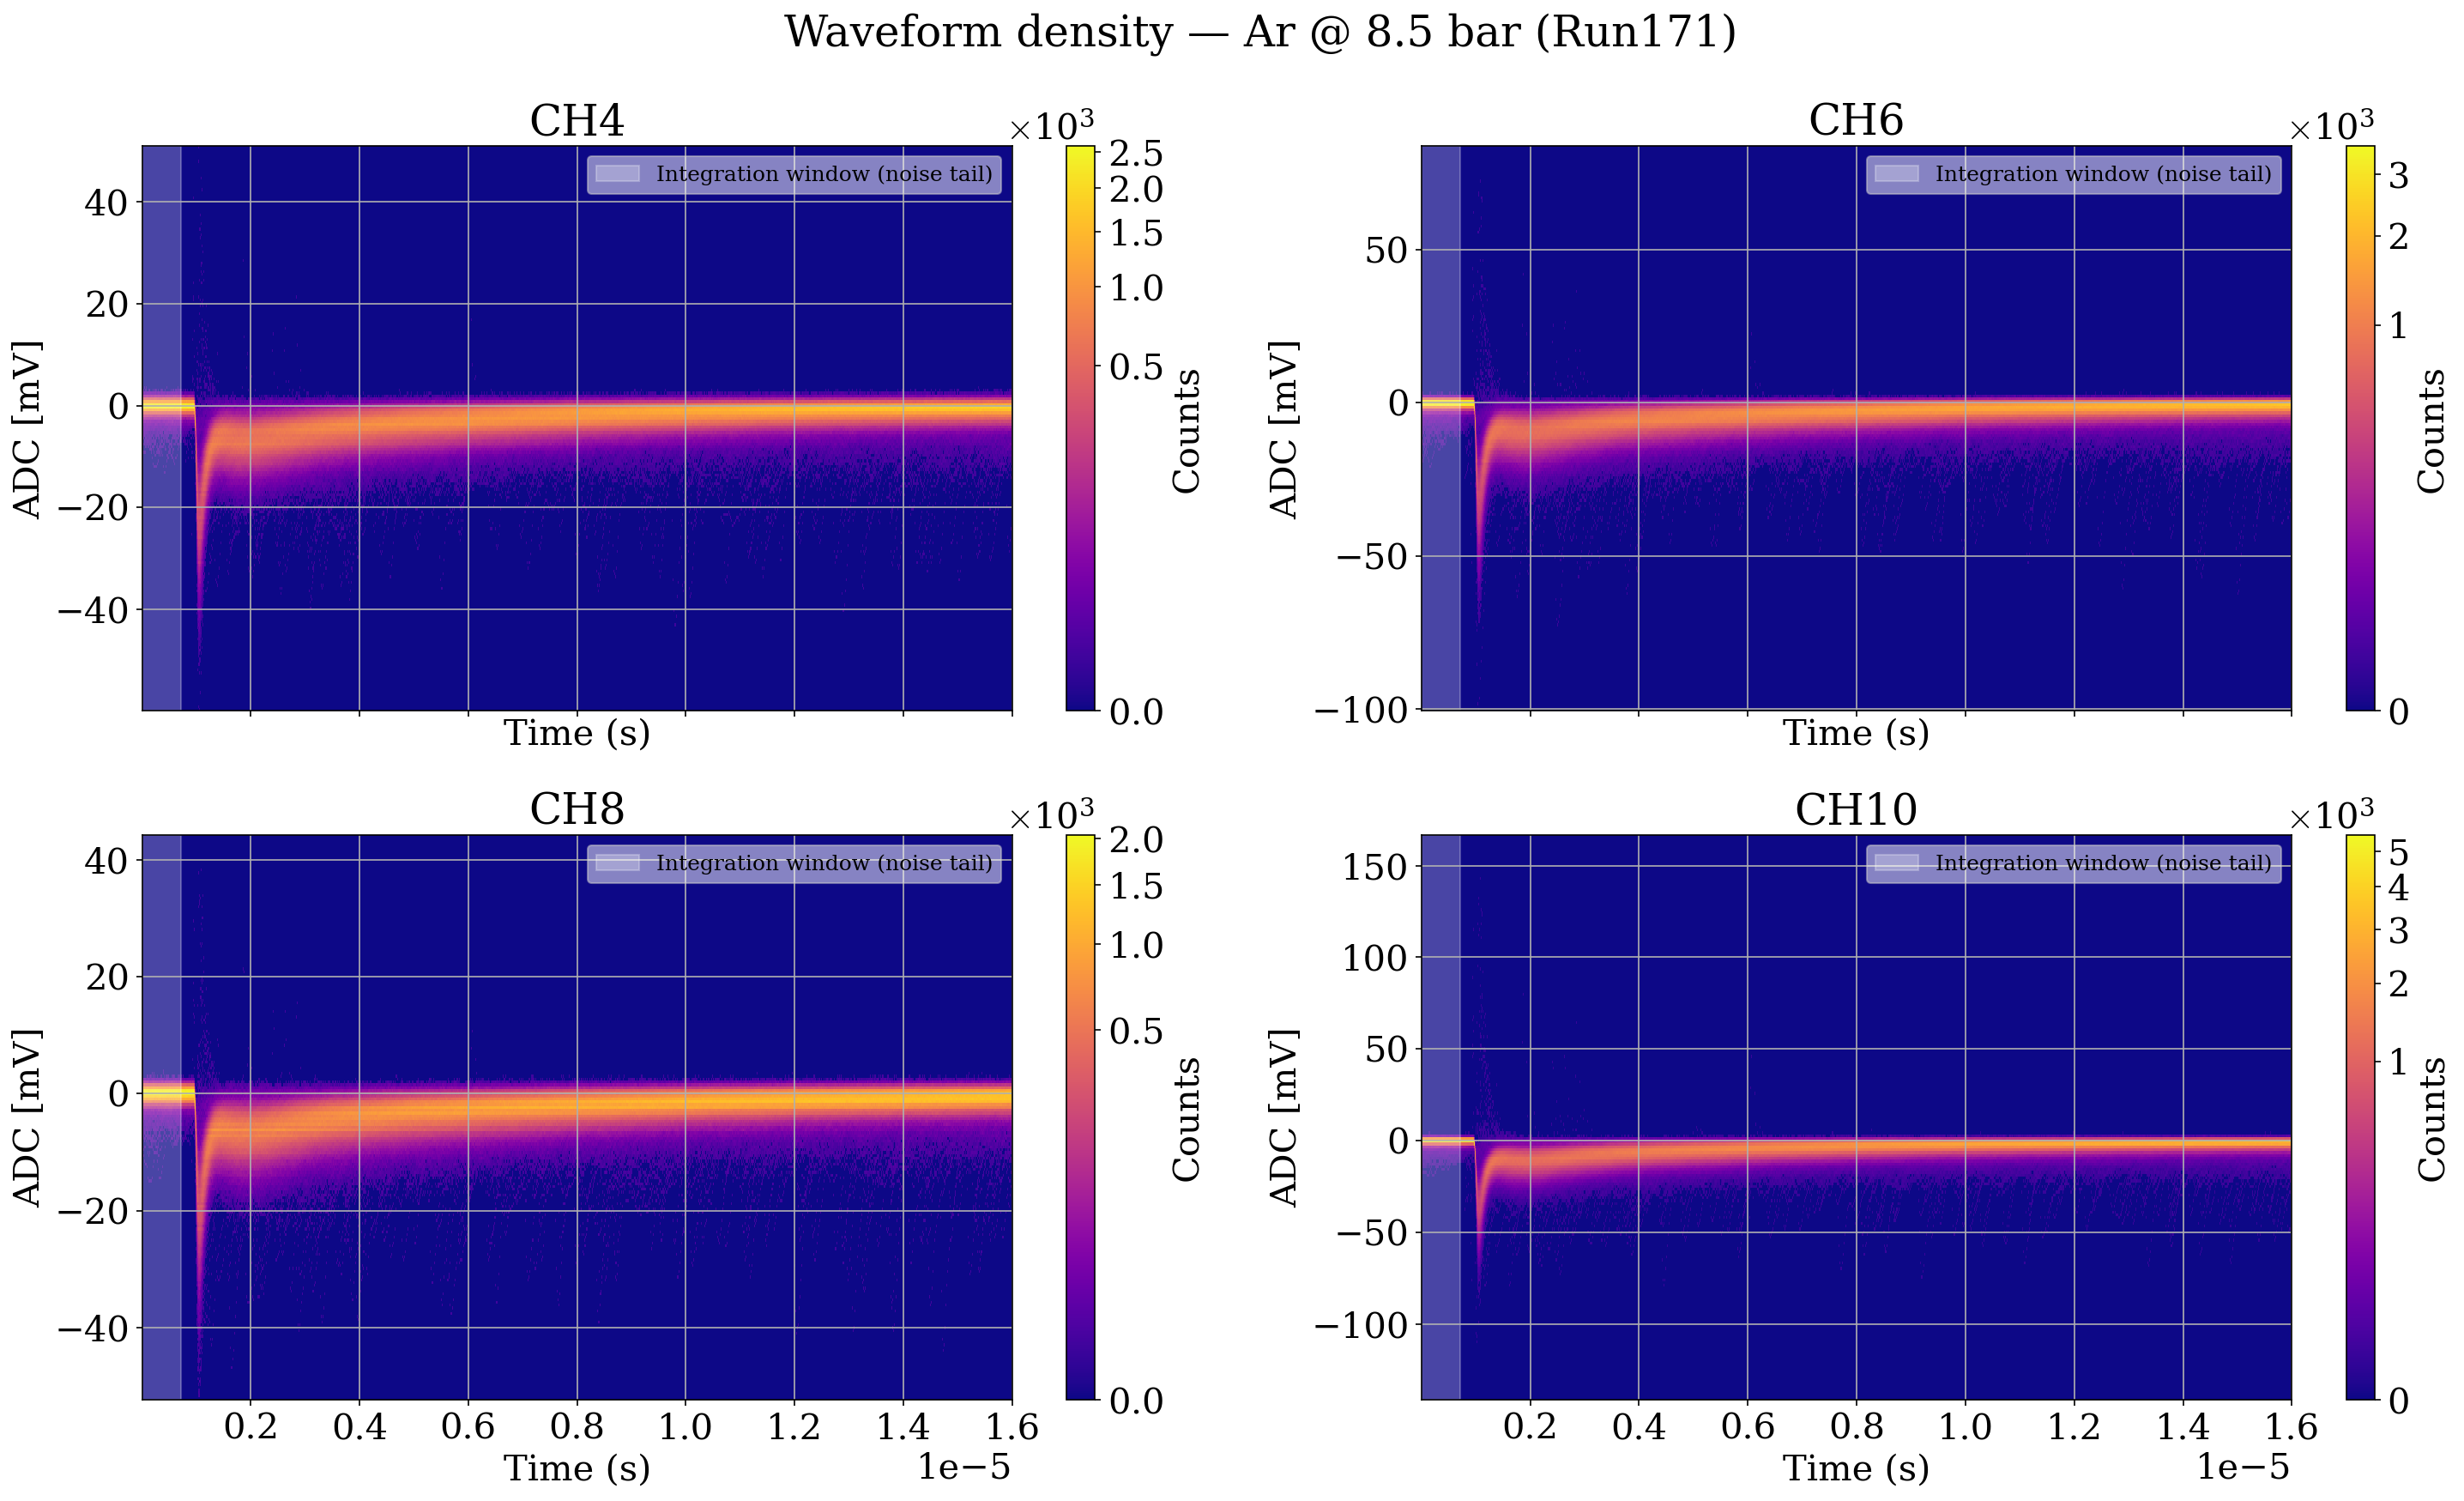

In [13]:
fig, axs = plot_waveform_density(df_example, nevents, channels, fixBaselines_noAmp, time, time_window, gas, example_pressure, run)

###  Charge distribution [p.e.]

In [14]:
def plot_charge_pes_distributions(df, nevents, channels, temp_label, gas, baselines, amp_factors,
                                   time_window, pressure, run, sample_binning=8e-9):
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
    fig.suptitle(f'Charge distribution (noise tail) — {gas} @ {pressure} bar ({run})')
    axs_flat = axs.flatten()

    charge_pes = {}
    for i, ch in enumerate(channels):
        channel = i + 1
        ax = axs_flat[i]
        charge_pes[channel], _, _ = compute_charge_pes(df, channels, i, temp_label, gas,
                                                       baselines, amp_factors, time_window,
                                                       sample_binning=sample_binning)

        vals = charge_pes[channel]
        counts, bins, _ = ax.hist(vals, bins=int(np.sqrt(nevents)),
                color=colors[i], alpha=0.5, label=ch)

        # zoom to the peak - the histogram above still covers the full data
        # range, but a sparse dark-count tail otherwise squashes the peak
        # into a sliver
        ax.set_xlim(bins[0], max(np.percentile(vals, 99), vals.mean() + 1))

        ax.set_xlabel('Charge [p.e.]')
        ax.set_ylabel('Waveforms')
        ax.grid(True)
        ax.legend(fontsize=font_size * 0.7)

    plt.tight_layout()
    plt.show()
    return charge_pes, fig, axs

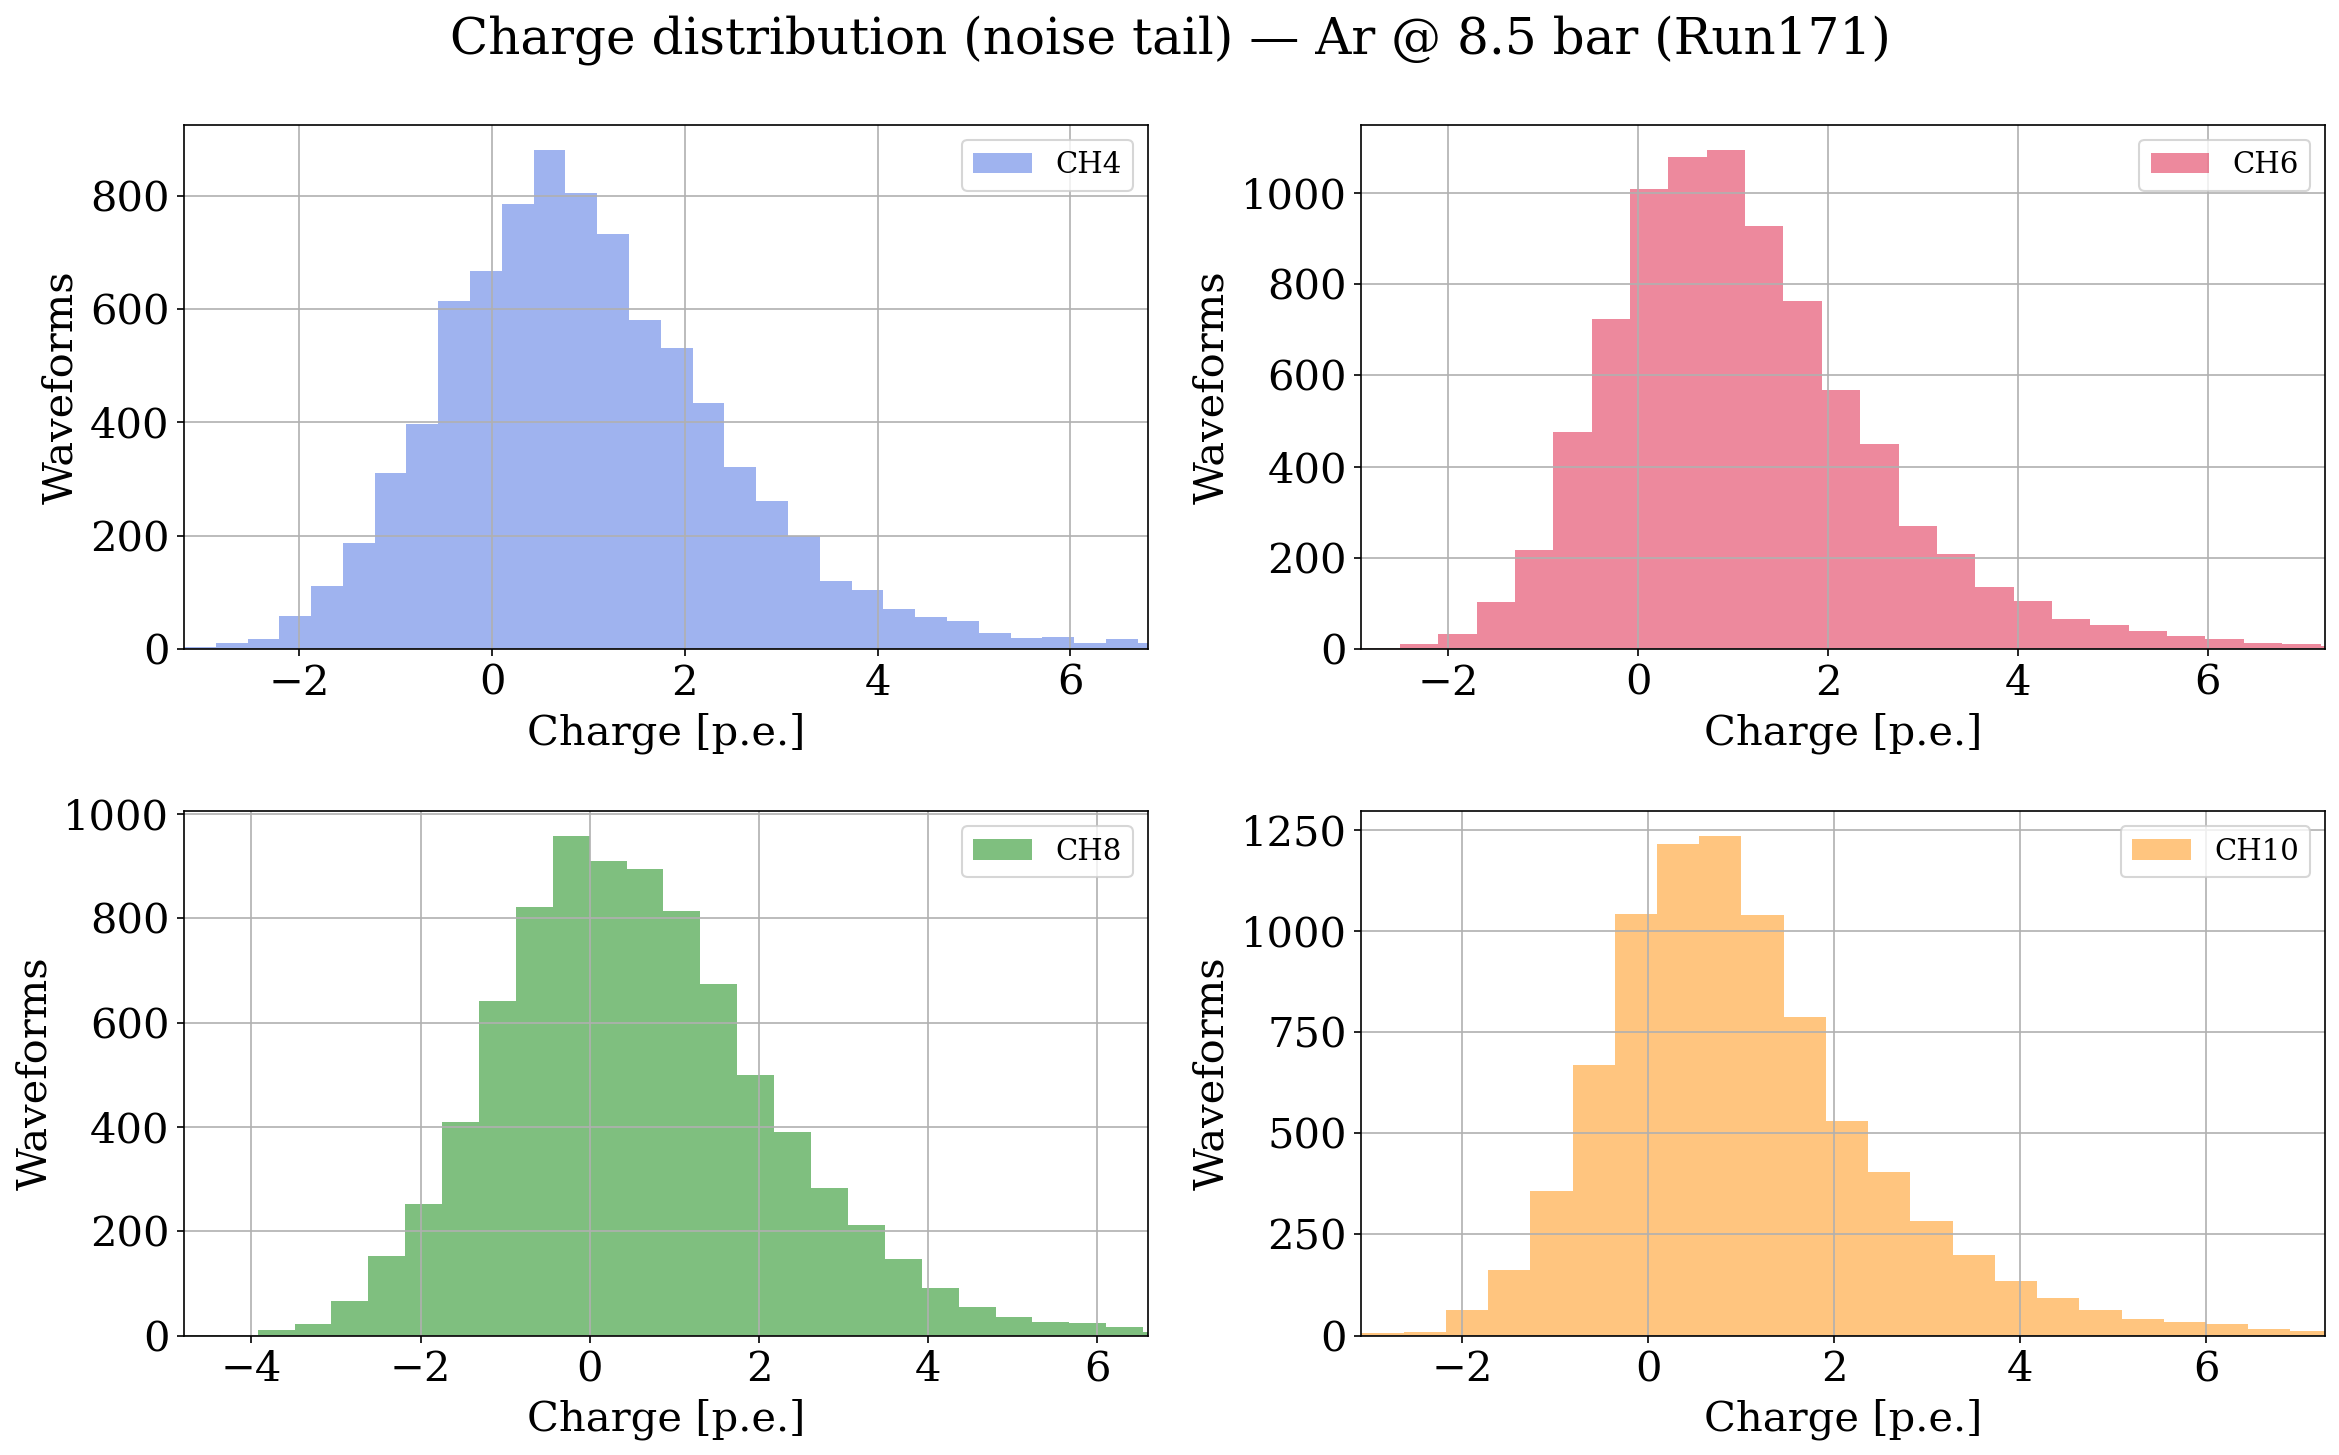

In [15]:
charge_pes_example, fig, axs = plot_charge_pes_distributions(df_example, nevents, channels, temp_label, gas
                                                             , fixBaselines_noAmp, amp_factors, time_window
                                                             , example_pressure, run)

###  Dark count rate distribution [MHz]

In [16]:
def plot_dcr_distributions(fits, gas, pressure, run=None):
    fig, axs = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
    title = f'Dark count rate — {gas} @ {pressure} bar'
    if run:
        title += f' ({run})'
    fig.suptitle(title)
    axs_flat = axs.flatten()

    for i, channel in enumerate([1, 2, 3, 4]):
        ax  = axs_flat[i]
        fit = fits[channel]

        ax.hist(fit['values'], bins=fit['bins'], color=colors[i], alpha=0.3, label=f'CH{channel}')

        x_fine = np.linspace(fit['bin_centers'][0], fit['bin_centers'][-1], 300)
        ax.plot(x_fine, cig.generalized_poisson_continuous(x_fine, *fit['popt']),
                color=colors[i], linestyle='-', lw=2,
                label=fr"$\mu$={fit['mu']:.2f}$\pm${fit['mu_err']:.2f} MHz, $\lambda$={fit['lam']*100:.1f}%")

        # zoom to the peak - the histogram/fit above still use the full data
        # range (the long dark-count tail matters for the fit), but a sparse
        # tail out to tens of MHz otherwise squashes the peak into a sliver
        ax.set_xlim(fit['bins'][0], max(np.percentile(fit['values'], 99), fit['mu'] + 1))

        ax.set_xlabel('Dark count rate [MHz]')
        ax.set_ylabel('Waveforms')
        ax.grid(True)
        ax.legend(fontsize=font_size * 0.7)

    plt.tight_layout()
    plt.show()
    return fig, axs

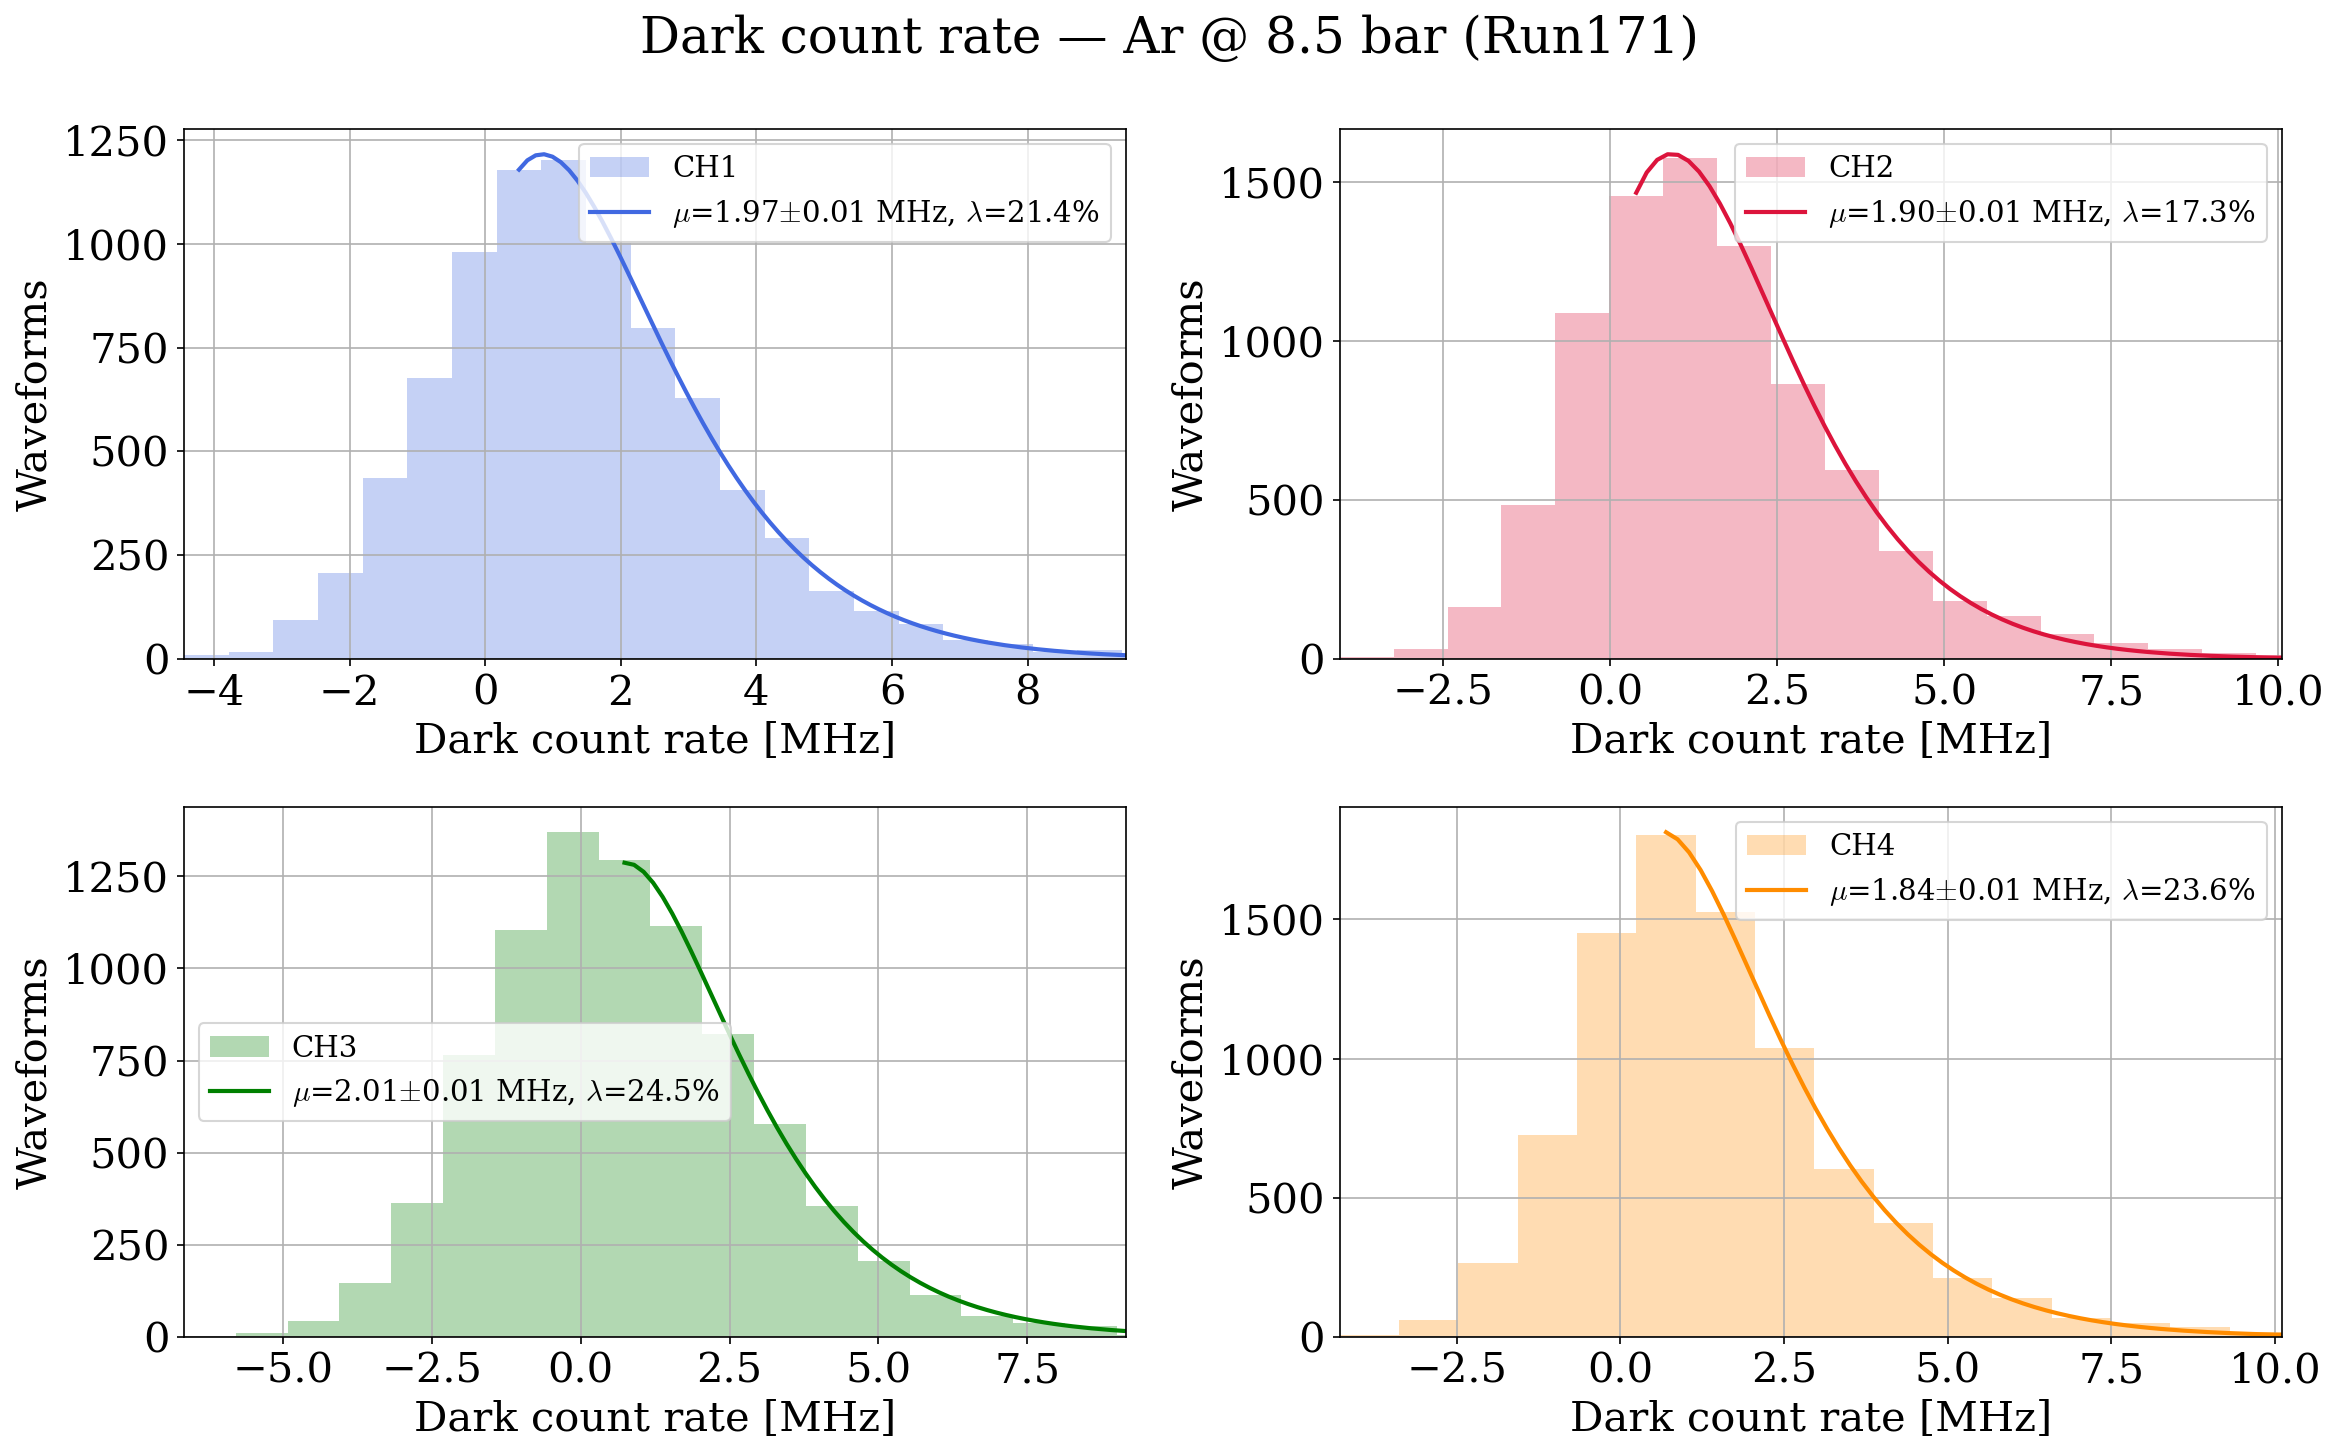

In [17]:
dcr_fits_example = {}
for i, ch in enumerate(channels):
    channel = i + 1
    dcr_values = compute_dcr_values(df_example, channels, i, temp_label, gas
                                    , baselines=fixBaselines_noAmp, amp_factors=amp_factors
                                    , time_window=time_window, sample_binning=sample_binning)
    fit           = fit_dcr_distribution(dcr_values)
    fit['values'] = dcr_values
    dcr_fits_example[channel] = fit

fig, axs = plot_dcr_distributions(dcr_fits_example, gas, example_pressure, run)

##  All pressures

The step above walked through one run; now repeat the same pipeline for every pressure of the chosen `gas`. Reading all files (`nfiles = None`) for 8 runs × 4 channels can take a while - lower `nfiles` above while testing.

In [18]:
all_pressures = False
if all_pressures:
    dcr_results = {}

    for pressure, run_p in tqdm(runs[gas].items(), desc=f'{gas} pressures'):
        temp_label_p = temperatures[gas][pressure]

        df_p = load_run(run_p, base, nchannels, nevents_per_wvf, samples_per_waveform,
                        event_header_bytes, start=start, nfiles=nfiles,
                        sample_binning=sample_binning)

        event_list_p = df_p['event'].unique()
        nevents_p    = len(event_list_p)

        t_matrix_p    = df_p['TIME'].values.reshape(nevents_p, -1)
        time_p        = t_matrix_p[0]
        time_window_p = time_p > time_window_max

        # recompute the baseline for this run - it's a property of each run, not a global constant
        fixBaselines_noAmp_p = compute_baselines(df_p, nevents_p, pretrigger, channels, gas, pressure, run_p, plot=True)

        dcr_results[pressure] = {}
        for i, ch in enumerate(channels):
            channel = i + 1
            dcr_values = compute_dcr_values(df_p, channels, i, temp_label_p, gas
                                            , baselines=fixBaselines_noAmp_p, amp_factors=amp_factors
                                            , time_window=time_window_p, sample_binning=sample_binning)
            fit           = fit_dcr_distribution(dcr_values)
            fit['values'] = dcr_values
            dcr_results[pressure][channel] = fit

##  Dark count rate vs pressure

In [19]:
def plot_dcr_vs_pressure(dcr_results, gas):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), dpi=150)
    ax.set_title(f'Dark count rate vs pressure — {gas}')

    pressures_sorted = sorted(dcr_results.keys())

    for i, channel in enumerate([1, 2, 3, 4]):
        mu_vals = [dcr_results[p][channel]['mu']     for p in pressures_sorted]
        mu_errs = [dcr_results[p][channel]['mu_err'] for p in pressures_sorted]

        ax.errorbar(pressures_sorted, mu_vals, yerr=mu_errs,
                    fmt=CB_MARKERS[i], color=colors[i], label=f'CH{channel}',
                    markersize=8, capsize=4)

    ax.set_xlabel('Pressure [bar]')
    ax.set_ylabel('Dark count rate [MHz]')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig, ax

In [20]:
if all_pressures:
    fig, ax = plot_dcr_vs_pressure(dcr_results, gas)

##  Save results

In [21]:
save_results = False
if (save_results) & (all_pressures):
    out_dir = f'{base}/dcr'
    os.makedirs(out_dir, exist_ok=True)
    with open(f'{out_dir}/dcr_results_{gas}.pkl', 'wb') as f:
        pickle.dump(dcr_results, f)
    print(f'Saved DCR results to {out_dir}/dcr_results_{gas}.pkl')